# 11 — Simple instruments

**Theme:** instruments that report a handful of values rather than a size
distribution.

A dosimeter, a gas monitor and a photometer all produce one or a few channels
over time. They reuse the whole `Aerosol1D` machinery — activities, time
operations, statistics, plotting — and add accessors named after what they
actually measure.

Instruments that do not count particles (gas monitors, environmental loggers,
the Partector) deliberately have **no** `total_concentration`: reporting a
chlorine reading as a particle number concentration would be wrong. Use their
own accessors instead.

In [1]:
import aerosoltools as at

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Partector — lung-deposited surface area

The Partector reports LDSA, the surface area of particles that deposits in the
lung. The TEM variant also samples particles onto grids for microscopy, and
records when it did so.

In [2]:
partector = at.load_partector_file("../../tests/data/Sample_Partector.txt")

print("instrument:", partector.instrument)
print("columns   :", list(partector.data))
print("unit      :", partector.unit)

⚠️ Warning: More than one TEM sampling period detected in ../../tests/data/Sample_Partector.txt
instrument: Partector
columns   : ['LDSA', 'TEM', 'Flow', 'All data', 'TEM grid sampling 1', 'TEM grid sampling 2']
unit      : {'LDSA': 'nm$^{2}$/cm$^{3}$', 'TEM': 'bool', 'Flow': 'l/min'}


In [3]:
print("LDSA :", partector.ldsa.head(3).tolist(), partector.unit)
print("flow :", partector.flow.head(3).tolist())

LDSA : [12.35, 12.1, 5.59] {'LDSA': 'nm$^{2}$/cm$^{3}$', 'TEM': 'bool', 'Flow': 'l/min'}
flow : [0.69, 0.6, 0.52]


`tem_samples` reports the grid-sampling periods, so microscopy results can be
tied back to the time series they came from.

In [4]:
partector.tem_samples

,Start,End,Sample_vol [ml]
0,2023-08-17 10:31:44,2023-08-17 11:40:48,30546.409142


Text(0.5, 1.0, 'Partector LDSA')

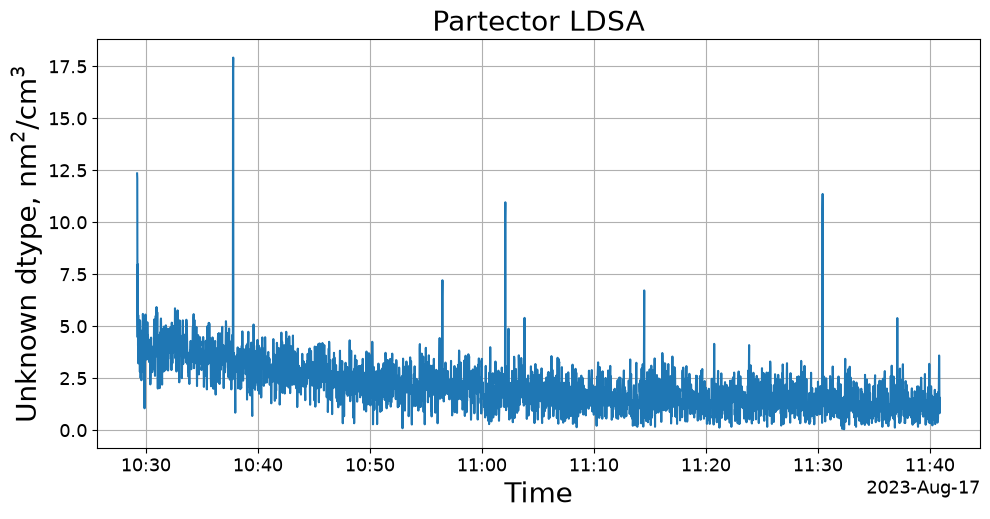

In [5]:
fig, ax = partector.plot_total_conc()
ax.set_title("Partector LDSA")

## DiSCmini — number, size and LDSA

The DiSCmini reports a particle number concentration, a mean particle size and
LDSA from the same measurement. It *does* count particles, so it keeps
`total_concentration`.

In [6]:
disc = at.load_discmini_file("../../tests/data/Sample_Discmini.txt")

print("columns:", list(disc.data))
print(f"number : {disc.total_concentration.mean():.0f} {disc.unit}")
print(f"size   : {disc.size.mean():.1f} nm")
print(f"LDSA   : {disc.ldsa.mean():.1f}")

columns: ['Total_conc', 'Size', 'LDSA', 'All data']
number : 19750 {'Total_conc': 'cm⁻³', 'Size': 'nm', 'LDSA': 'nm²/cm³'}
size   : 30.9 nm
LDSA   : 25.8


Mean size is a single number, not a distribution — the DiSCmini cannot
distinguish a narrow distribution from a wide one with the same mean. For that
you need a sizing instrument, see [8 — PSD fitting](08-psd-fitting.ipynb).

## DustTrak — PM mass fractions

The DustTrak DRX reports the standard mass fractions simultaneously.

In [7]:
dust = at.load_dusttrak_file("../../tests/data/Sample_DustTrak.csv")

print("instrument   :", dust.instrument)
print("serial number:", dust.serial_number)
print("columns      :", list(dust.data))
print("units        :", dust.column_units)

instrument   : DustTrak DRX
serial number: 8533151303
columns      : ['PM1', 'PM2.5', 'PM4', 'PM10', 'Total', 'All data']
units        : {}


In [8]:
print(f"PM1   {dust.pm1.mean():7.1f}")
print(f"PM2.5 {dust.pm2_5.mean():7.1f}")
print(f"PM4   {dust.pm4.mean():7.1f}")
print(f"PM10  {dust.pm10.mean():7.1f}")
print(f"Total {dust.total.mean():7.1f}   (all in ug/m3)")

PM1      94.7
PM2.5   103.5
PM4     111.8
PM10    141.6
Total   201.2   (all in ug/m3)


The fractions are cumulative, so each is at least as large as the one below it.
The gaps between them describe the coarseness of the aerosol.

Text(0.5, 1.0, 'DustTrak cumulative mass fractions')

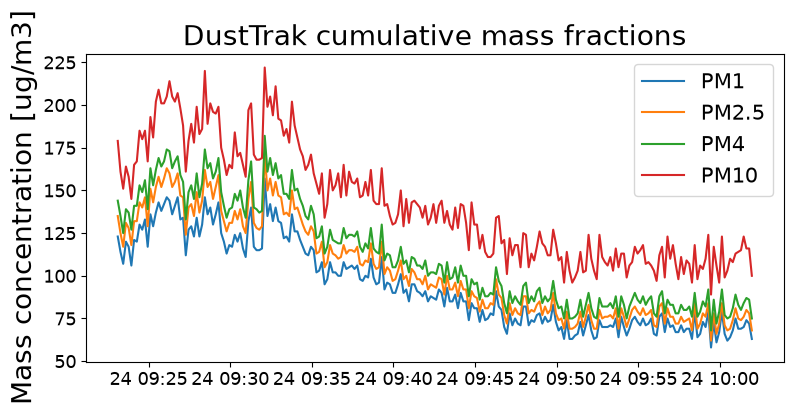

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
for name in ["pm1", "pm2_5", "pm4", "pm10"]:
    ax.plot(dust.time, getattr(dust, name), label=name.upper().replace("_", "."))
ax.set_ylabel("Mass concentration [ug/m3]")
ax.legend()
ax.set_title("DustTrak cumulative mass fractions")

## Gas monitors

`Gas1D` covers instruments measuring one gas at a time. The reading is always
`.concentration`; which gas it is lives in `.dtype`. That split means the same
code works whatever the instrument is configured for.

A Ranger uses interchangeable heads, so one file can contain several
components — the loader returns one object per component.

In [10]:
loaded = at.load_ranger_file("../../tests/data/Ranger_2605-1000088-A_20260612-0603.csv")
objects = loaded if isinstance(loaded, list) else [loaded]

for obj in objects:
    dtype = obj.dtype if not isinstance(obj.dtype, dict) else "PM channels"
    print(f"{type(obj).__name__:12s} {str(dtype):14s} {len(obj.data):5d} samples")

Aerosol1D    PM channels       21 samples
Gas1D        Cl₂             1578 samples
Gas1D        NO₂             1409 samples


In [11]:
chlorine = next(o for o in objects if o.dtype == "Cl₂")

print(f"gas   : {chlorine.dtype}")
print(f"unit  : {chlorine.unit}")
print(f"mean  : {chlorine.concentration.mean():.4f} {chlorine.unit}")

gas   : Cl₂
unit  : ppm
mean  : 0.2685 ppm


A Tiger VOC monitor is the same class with a different gas, so the same
accessor works unchanged.

In [12]:
tiger = at.load_tiger_file("../../tests/data/Sample_Tiger.csv")

print(f"gas   : {tiger.dtype}")
print(f"unit  : {tiger.unit}")
print(f"mean  : {tiger.concentration.mean():.1f} {tiger.unit}")

gas   : TVOC
unit  : ppb
mean  : 19.9 ppb


Text(0.5, 1.0, 'Tiger TVOC')

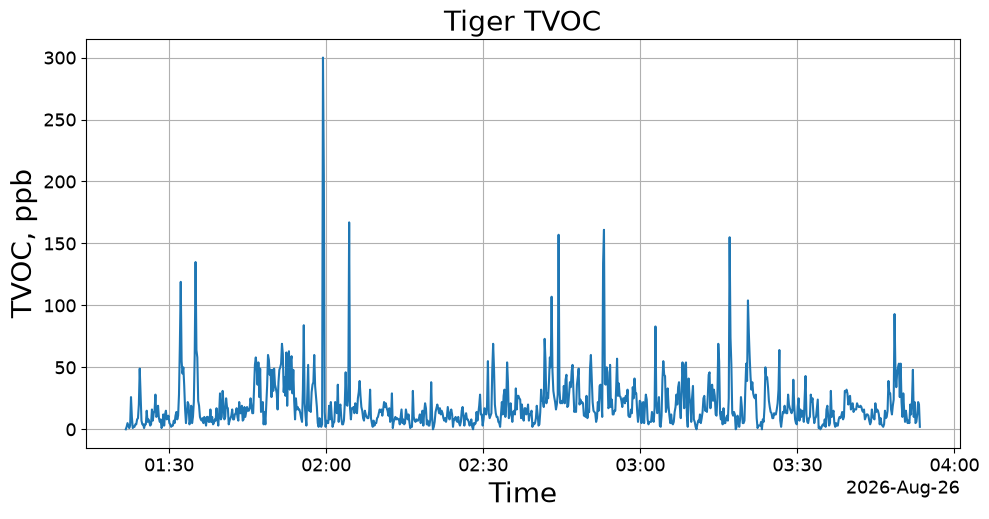

In [13]:
fig, ax = tiger.plot_total_conc()
ax.set_title(f"Tiger {tiger.dtype}")

## Environmental loggers

`Environmental1D` covers temperature, humidity and related channels. Only the
channels actually present in the file are available.

In [14]:
env = at.load_fourtec_file("../../tests/data/Sample_Fourtec.xlsx")

print("columns:", list(env.data))
print(f"temperature: {env.temperature.mean():.2f} degC")
print(f"RH         : {env.rh.mean():.1f} %")

columns: ['Temperature', 'RH', 'All data']
temperature: 22.70 degC
RH         : 46.6 %


Asking for a channel the file does not contain raises a message naming what
*is* available, rather than a bare `KeyError`.

In [15]:
try:
    env.pressure
except AttributeError as err:
    print("AttributeError:", err)

AttributeError: Environmental1D has no 'Pressure' channel in this file; available channels: Temperature, RH, All data.


## The shared contract

Non-particle instruments raise on `total_concentration` by design.

In [16]:
for obj, label in [(tiger, "Gas1D"), (env, "Environmental1D"),
                   (partector, "Partector")]:
    try:
        obj.total_concentration
        print(f"{label:16s} has total_concentration")
    except AttributeError:
        print(f"{label:16s} correctly has no total_concentration")

Gas1D            correctly has no total_concentration
Environmental1D  correctly has no total_concentration
Partector        correctly has no total_concentration


Everything else does work on them — activities, cropping, summaries, plotting —
because they are ordinary `Aerosol1D` objects underneath.

In [17]:
tiger.mark_activities({
    "Weaving": [(str(tiger.time[100]), str(tiger.time[400]))],
})
tiger.summarize_activities()


Summary of aerosol metrics per activity:

+------------------+----------+---------+
|                  | All data | Weaving |
+------------------+----------+---------+
| Duration (HH:MM) |  02:31   |  00:50  |
| TVOC [ppb] mean  |  19.917  | 19.179  |
|  TVOC [ppb] std  |  22.149  | 25.802  |
+------------------+----------+---------+


,Segment,Duration (HH:MM),TVOC [ppb] mean,TVOC [ppb] std
0,All data,02:31,19.917,22.149
1,Weaving,00:50,19.179,25.802


---

**Next:** [12 — Aethalometer](12-aethalometer.ipynb).